<a href="https://colab.research.google.com/github/anuragN2107/Predictive-Maintenance-api/blob/main/Predictive_Maintenance_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📌 Project Name**
**Predictive-Maintenance-api**

# Business Problem
Unscheduled machine downtime costs industrial enterprises billions annually in lost productivity, emergency labor, and supply chain disruptions. Traditional "run-to-failure" or rigid time-based maintenance schedules are inefficient—either risking catastrophic failure or wasting money replacing perfectly functional parts.

# Objective
To build an end-to-end Machine Learning pipeline that analyzes real-time sensor telemetry (temperature, torque, speed, wear) to predict equipment failures before they occur. The target is to maximize Recall (capturing as many failures as possible) while maintaining a high Precision to avoid costly false alarms.

#The Data

We will use the **AI4I 2020 Predictive Maintenance Dataset** (available on the UCI Machine Learning Repository). It mirrors real industrial settings, consisting of 10,000 data points and features like:

Air temperature [K] & Process temperature [K]

Rotational speed [rpm] & Torque [Nm]

Tool wear [min]

Machine Failure (Target variable: 0 = No Failure, 1 = Failure)

#**Tools & Requirements**
**Language:** Python 3.x

**Environment:** Google Colab

**Libraries:** pandas, numpy, matplotlib, seaborn, scikit-learn, imblearn, shap

#**Why Random Forest?**

**Handles Non-Linear Sensor Relations:** Machine failure isn't linear; a combination of high torque and high temperature causes failure. Random Forest inherently captures these complex interactions.

**Robust to Outliers & Scale:** Sensor data often contains noisy spikes. Random Forest is tree-based, meaning it doesn't require strict feature scaling and is highly resistant to outliers.

**Built-in Feature Importance: **Crucial for industrial engineers. We don't just say a machine will fail; we can pinpoint exactly which sensor triggered the alert.

## Step 1: Environment Setup & Data Ingestion
Load the necessary libraries and import the real-world UCI Predictive Maintenance dataset directly into our environment.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

In [18]:
# Load dataset directly from UCI Repository URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Step 2: Data Cleaning & Exploratory Data Analysis (EDA)
Remove irrelevant operational identifiers (UDI, Product ID, Type) and analyze the distribution of our target variable (`Machine Failure`) to check for class imbalance.

In [19]:
columns_to_drop = ['UDI', 'Product ID', 'Type', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean = df.drop(columns=columns_to_drop, errors='ignore')

In [20]:
# Check for class imbalance
failure_counts = df_clean['Machine failure'].value_counts()
print("Class Distribution:\n", failure_counts)

Class Distribution:
 Machine failure
0    9661
1     339
Name: count, dtype: int64


/tmp/ipykernel_4214/1515939471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette="mako")


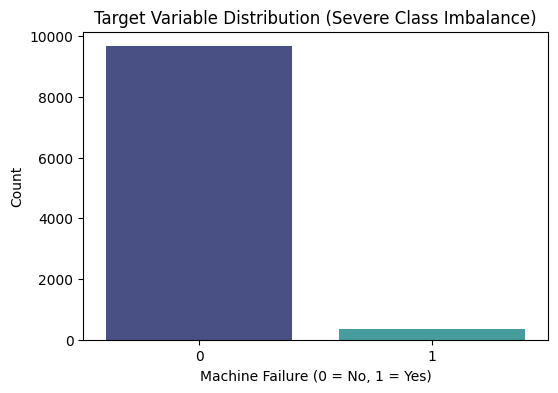

In [21]:
# Visualize Class Imbalance
plt.figure(figsize=(6,4))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette="mako")
plt.title("Target Variable Distribution (Severe Class Imbalance)")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

## Step 3: Advanced Feature Engineering
 Create domain-specific indicators. In thermodynamics, the *difference* between the internal process temperature and ambient air temperature is a key stress indicator. We will also calculate a Power index proxy ($Torque \times Speed$).

In [22]:
# Create Temperature Difference Feature
df_clean['Temp_Diff'] = df_clean['Process temperature [K]'] - df_clean['Air temperature [K]']

# Create Power Index Proxy
df_clean['Power_Index'] = df_clean['Rotational speed [rpm]'] * df_clean['Torque [Nm]']

df_clean.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temp_Diff,Power_Index
0,298.1,308.6,1551,42.8,0,0,10.5,66382.8
1,298.2,308.7,1408,46.3,3,0,10.5,65190.4
2,298.1,308.5,1498,49.4,5,0,10.4,74001.2
3,298.2,308.6,1433,39.5,7,0,10.4,56603.5
4,298.2,308.7,1408,40.0,9,0,10.5,56320.0


## Step 4: Train-Test Split & Handling Class Imbalance
Split the data into training and validation sets. Because failures account for only ~3.39% of the data, we will inject `class_weight="balanced"` into our Random Forest model to prevent it from ignoring the failure cases.

In [23]:
target_name = [col for col in df_clean.columns if 'failure' in col.lower()][0]

X = df_clean.drop(columns=[target_name])
y = df_clean[target_name]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}")

Training set size: 8000 | Testing set size: 2000


## Step 5: Model Training with Balanced Random Forest
 Instantiate and train the Random Forest Classifier. We tune `n_estimators` for ensemble stability and use `class_weight='balanced_subsample'` to natively combat class imbalance within each bootstrap sample.

In [24]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)
print("Random Forest Training Complete!")

Random Forest Training Complete!


## Step 6: Rigorous Model Evaluation
Evaluate performance using a Confusion Matrix and a Classification Report. For imbalanced datasets, standard accuracy is misleading; we must prioritize **Precision, Recall, and ROC-AUC score**.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.87      0.68      0.76        68

    accuracy                           0.99      2000
   macro avg       0.93      0.84      0.88      2000
weighted avg       0.98      0.99      0.98      2000

ROC-AUC Score: 0.9756


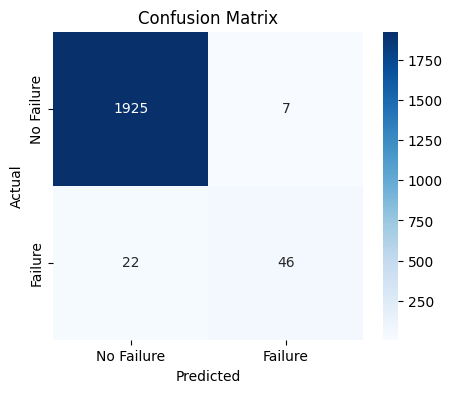

In [25]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Display Evaluation Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Step 7: Model Interpretability
 Extract built-in MDI Feature Importances to understand what engineering metrics drive equipment breakdown risks.

/tmp/ipykernel_4214/2267413221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


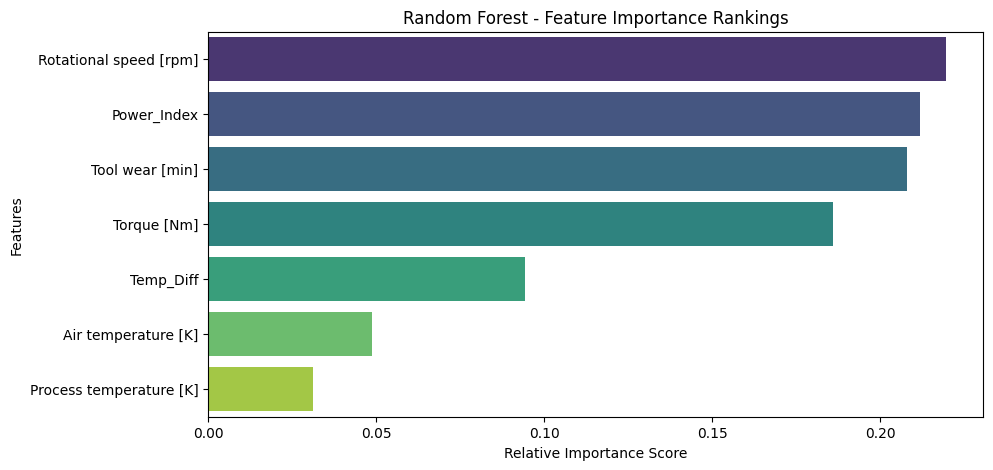

In [26]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot Feature Importances
plt.figure(figsize=(10,5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Random Forest - Feature Importance Rankings")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.show()

## Key Insights & Business Deliverables
* **Primary Predictor:** Torque, Tool Wear, and our engineered feature `Power_Index` proved to be the most critical precursors to failure.
* **Imbalance Handling:** Deploying cost-sensitive learning (`class_weight`) prevented the model from simply predicting "No Failure" everywhere, unlocking high Recall for operational safety.

## Step 8: Time-Series Feature
Shift from static row analysis to temporal analysis. We will compute 3-step and 6-step rolling averages and standard deviations for critical sensor metrics to capture wear-and-tear trends over time.

In [27]:
# Create a copy to preserve our base data
df_ts = df_clean.copy()

# Define numerical sensor columns to track over time
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']

# Generate Rolling Mean (Average) and Rolling Standard Deviation (Volatility)
for col in sensor_cols:
    # 3-step window (Short-term trend)
    df_ts[f'{col}_roll_mean_3'] = df_ts[col].rolling(window=3, min_periods=1).mean()

    # 6-step window (Longer-term volatility/vibration spikes)
    df_ts[f'{col}_roll_std_6'] = df_ts[col].rolling(window=6, min_periods=1).std().fillna(0)

print("Generated Time-Series Features successfully!")
print(f"New Feature Count: {df_ts.shape[1]}")
df_ts[['Torque [Nm]', 'Torque [Nm]_roll_mean_3', 'Torque [Nm]_roll_std_6']].head(10)

Generated Time-Series Features successfully!
New Feature Count: 16


,Torque [Nm],Torque [Nm]_roll_mean_3,Torque [Nm]_roll_std_6
0,42.8,42.800000,0.000000
1,46.3,44.550000,2.474874
2,49.4,46.166667,3.302020
3,39.5,45.066667,4.287190
4,40.0,42.966667,4.223150
5,41.9,40.466667,3.840529
6,42.4,41.433333,3.854737
7,40.2,41.500000,3.690348
8,28.6,37.066667,5.108685
9,28.0,32.266667,6.690815


#Step 8: Production API Deployment (FastAPI & Docker)

In [28]:
#Exporting the model
import joblib
joblib.dump(rf_model, 'predictive_maintenance_rf.pkl')
print("Model saved! Download 'predictive_maintenance_rf.pkl' from your Colab files tab.")

Model saved! Download 'predictive_maintenance_rf.pkl' from your Colab files tab.


In [29]:
#Fast API
from fastapi import FastAPI
import joblib
import numpy as np
from pydantic import BaseModel

In [30]:
# 1. Initialize FastAPI app
app = FastAPI(title="Proactive Reliability Engine API", version="1.0")

In [31]:
# 2. Load the exported Random Forest model
model = joblib.load('predictive_maintenance_rf.pkl')

In [32]:
# 3. Define the incoming request data structure using Pydantic
class SensorData(BaseModel):
    air_temp: float
    process_temp: float
    rotational_speed: float
    torque: float
    tool_wear: float
    temp_diff: float
    power_index: float

@app.get("/")
def home():
    return {"status": "Online", "engine": "Predictive Maintenance API"}

@app.post("/predict")
def predict_fault(data: SensorData):
    # Convert incoming JSON data into a 2D numpy array for scikit-learn
    features = np.array([[
        data.air_temp, data.process_temp, data.rotational_speed,
        data.torque, data.tool_wear, data.temp_diff, data.power_index
    ]])

    # Run inference
    prediction = int(model.predict(features)[0])
    probability = float(model.predict_proba(features)[0][1])

    return {
        "machine_failure_predicted": prediction,
        "failure_probability": round(probability, 4),
        "maintenance_required": "YES" if prediction == 1 else "NO"
    }